In [8]:
import csv
import json
import os
import random
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import Aer
from qiskit.visualization import circuit_drawer

# ===================== CONFIGURATION =====================
NUM_CIRCUITS = 100
NUM_QUBITS = 5
SHOTS = 1024
CSV_FILENAME = "circuit_results.csv"
IMG_DIR = "circuit_images"
SIMULATOR = Aer.get_backend('qasm_simulator')

# Probabilities for gate sizes (adjust as you like)
P_SINGLE = 0.6      # rx, ry, rz on 1 qubit
P_TWO = 0.25         # cx (CNOT)
P_THREE = 0.08       # ccx (Toffoli, 3-qubit)
P_FOUR = 0.05        # mcx with 3 controls (4-qubit)
P_FIVE = 0.02        # mcx with 4 controls (5-qubit)

# ===================== CIRCUIT GENERATION =====================
def random_angle():
    return random.uniform(0, 2 * np.pi)

def random_single_qubit_gate(circuit, qubit):
    gate = random.choice(['rx', 'ry', 'rz'])
    angle = random_angle()
    if gate == 'rx':
        circuit.rx(angle, qubit)
    elif gate == 'ry':
        circuit.ry(angle, qubit)
    else:
        circuit.rz(angle, qubit)

def random_two_qubit_gate(circuit, q1, q2):
    circuit.cx(q1, q2)

def random_three_qubit_gate(circuit, q1, q2, q3):
    circuit.ccx(q1, q2, q3)

def random_four_qubit_gate(circuit, q1, q2, q3, q4):
    circuit.mcx([q1, q2, q3], q4)   # 3 controls, 1 target

def random_five_qubit_gate(circuit, q1, q2, q3, q4, q5):
    circuit.mcx([q1, q2, q3, q4], q5)   # 4 controls, 1 target

def generate_random_circuit():
    """5‑qubit circuit with parallel layers of gates sized 1 to 5."""
    circuit = QuantumCircuit(NUM_QUBITS)
    depth = random.randint(5, 15)   # number of layers

    for _ in range(depth):
        free_qubits = set(range(NUM_QUBITS))
        layer_gates = []   # (gate_function, qubit_list)

        while free_qubits:
            # Choose gate size according to probabilities
            r = random.random()
            if r < P_SINGLE:
                size = 1
            elif r < P_SINGLE + P_TWO:
                size = 2
            elif r < P_SINGLE + P_TWO + P_THREE:
                size = 3
            elif r < P_SINGLE + P_TWO + P_THREE + P_FOUR:
                size = 4
            else:
                size = 5

            if len(free_qubits) < size:
                break   # not enough qubits left

            chosen = sorted(random.sample(list(free_qubits), size))
            free_qubits -= set(chosen)

            # Pick the appropriate gate function
            if size == 1:
                fn = random_single_qubit_gate
            elif size == 2:
                fn = random_two_qubit_gate
            elif size == 3:
                fn = random_three_qubit_gate
            elif size == 4:
                fn = random_four_qubit_gate
            else:
                fn = random_five_qubit_gate

            layer_gates.append((fn, chosen))

        # Apply all gates of this layer (they act on disjoint qubits → parallel)
        for gate_fn, qubits in layer_gates:
            gate_fn(circuit, *qubits)

        circuit.barrier()   # optional visual separation between layers

    return circuit

# ===================== SIMULATION =====================
def simulate_circuit(circuit):
    """Run on the local simulator and return counts dictionary."""
    transpiled = transpile(circuit, SIMULATOR)
    job = SIMULATOR.run(transpiled, shots=SHOTS)
    return job.result().get_counts(transpiled)

# ===================== DRAWING & SAVING IMAGES =====================
def draw_circuit(circuit, filepath):
    """Save a matplotlib drawing of the circuit as a PNG."""
    circuit_drawer(circuit, output='mpl', filename=filepath)

# ===================== CSV STORAGE =====================
def save_results_to_csv(data, filename):
    fieldnames = ['circuit_id', 'circuit_qasm', 'theoretical_counts',
                  'practical_counts', 'image_path']
    with open(filename, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames, extrasaction='ignore')
        writer.writeheader()
        writer.writerows(data)

# ===================== MAIN =====================
def main():
    os.makedirs(IMG_DIR, exist_ok=True)
    all_results = []

    print(f"Generating and simulating {NUM_CIRCUITS} random circuits...")
    for i in range(NUM_CIRCUITS):
        # 1. Create circuit
        qc = generate_random_circuit()

        # 2. Draw and save image
        img_path = os.path.join(IMG_DIR, f"circuit_{i:03d}.png")
        draw_circuit(qc, img_path)

        # 3. Simulate
        counts = simulate_circuit(qc)

        # 4. Prepare row for CSV
        row = {
            'circuit_id': i,
            'circuit_qasm': qc.qasm(),
            'theoretical_counts': json.dumps(counts),
            'practical_counts': json.dumps({}),   # placeholder for future hardware run
            'image_path': img_path
        }
        all_results.append(row)

        if (i+1) % 10 == 0:
            print(f"  {i+1}/{NUM_CIRCUITS} done.")

    # 5. Write CSV
    save_results_to_csv(all_results, CSV_FILENAME)
    print(f"\n✅ All results saved to {CSV_FILENAME}")
    print(f"✅ Circuit images saved in folder: {IMG_DIR}")

# if __name__ == "__main__":
#     main()

ZERO NOISE EXTRAPOLATION DEMONSTRATION
Original circuit:
     ┌───┐     ┌─────────┐
q_0: ┤ H ├──■──┤ Rx(0.5) ├
     └───┘┌─┴─┐├─────────┤
q_1: ─────┤ X ├┤ Ry(0.3) ├
          └───┘└─────────┘
------------------------------------------------------------
Running with noise scale x = 1...
  E(1) = 0.015625
Running with noise scale x = 3...
  E(3) = -0.013184
Running with noise scale x = 5...
  E(5) = 0.007568
Running with noise scale x = 7...
  E(7) = -0.000732
Running with noise scale x = 9...
  E(9) = 0.016846

RESULTS
E₀ (Least-Squares, deg=2): 0.020845
E₀ (Richardson):            0.048615
E₀ (Exponential):           0.0015025005388267232


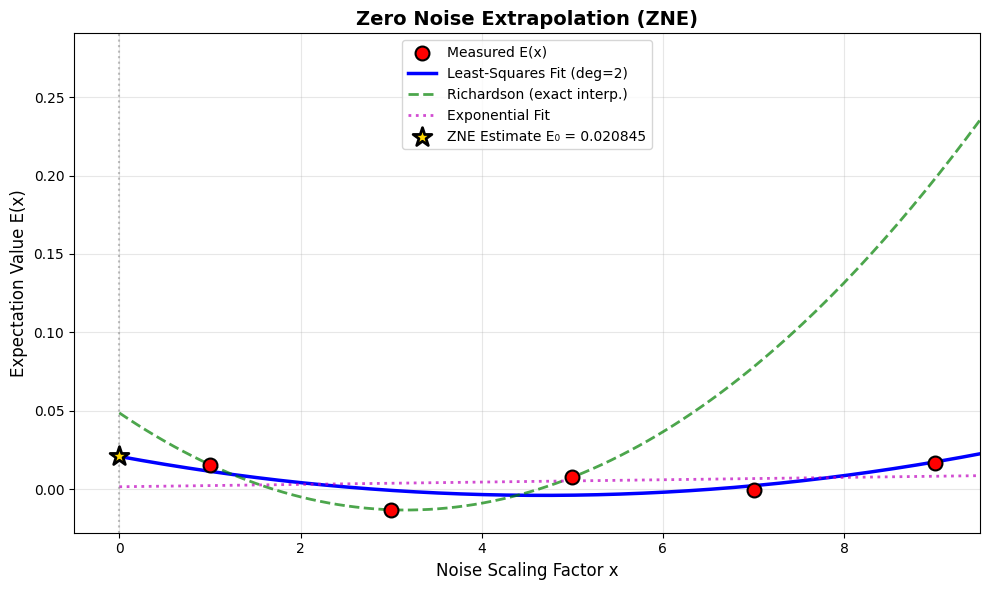

In [7]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import Statevector, Operator
from qiskit.circuit.library import PauliEvolutionGate
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import lagrange
from numpy.polynomial.polynomial import Polynomial


def zne_extrapolation(qc, scaling_factors=[1, 3, 5, 7, 9], 
                      observable=None, 
                      extrapolation_degree=2,
                      shots=8192,
                      noise_model=None):
    """
    Zero Noise Extrapolation (ZNE) for a quantum circuit.
    
    Parameters:
    -----------
    qc : QuantumCircuit
        The input quantum circuit
    scaling_factors : list
        Noise scaling factors to use (default: [1,3,5,7,9])
    observable : callable or None
        Function that takes counts dict and returns expectation value.
        If None, uses Z-basis measurement of first qubit.
    extrapolation_degree : int
        Degree of polynomial for extrapolation (default: 2)
    shots : int
        Number of shots per circuit execution
    noise_model : NoiseModel or None
        Qiskit noise model. If None, creates depolarizing noise.
    
    Returns:
    --------
    dict with 'E0_estimate', 'curve_data', 'coefficients', 'plot'
    """
    
    n_qubits = qc.num_qubits
    
    # ========== STEP 1: Create Noise Model if not provided ==========
    if noise_model is None:
        noise_model = NoiseModel()
        # Add depolarizing error to single-qubit gates
        error_1q = depolarizing_error(0.01, 1)  # 1% depolarizing
        noise_model.add_all_qubit_quantum_error(error_1q, ['u1', 'u2', 'u3', 'rx', 'ry', 'rz'])
        # Add depolarizing error to two-qubit gates
        error_2q = depolarizing_error(0.02, 2)  # 2% depolarizing
        noise_model.add_all_qubit_quantum_error(error_2q, ['cx', 'cz'])
    
    # ========== STEP 2: Define Observable ==========
    if observable is None:
        # Default: measure <Z> on first qubit
        def default_observable(counts):
            if not counts:
                return 0.0
            total = sum(counts.values())
            # P(0) - P(1) for first qubit
            p0 = sum(v for k, v in counts.items() if k[-1] == '0') / total
            p1 = sum(v for k, v in counts.items() if k[-1] == '1') / total
            return p0 - p1
        observable = default_observable
    
    # ========== STEP 3: Gate Folding Function ==========
    def fold_circuit(circuit, scale_factor):
        """
        Fold circuit by inserting U†U pairs to amplify noise.
        scale_factor must be odd integer: 1, 3, 5, 7, 9...
        """
        if scale_factor == 1:
            return circuit.copy()
        
        if scale_factor % 2 == 0:
            raise ValueError("Scaling factor must be odd integer")
        
        # Number of U†U blocks to insert
        n_blocks = (scale_factor - 1) // 2
        
        folded = QuantumCircuit(circuit.num_qubits, circuit.num_clbits)
        
        for inst in circuit.data:
            op, qargs, cargs = inst.operation, inst.qubits, inst.clbits
            
            # Skip measurements and barriers
            if op.name in ['measure', 'barrier']:
                folded.append(op, qargs, cargs)
                continue
            
            # Add original gate
            folded.append(op, qargs, cargs)
            
            # Add U†U blocks
            for _ in range(n_blocks):
                # Add inverse (U†)
                if hasattr(op, 'inverse'):
                    folded.append(op.inverse(), qargs, cargs)
                else:
                    # For gates without inverse method, use unitary simulation
                    # This is a simplification - in practice use proper inverse
                    folded.append(op, qargs, cargs)  # placeholder
                    folded.append(op, qargs, cargs)
                
                # Add original again (U)
                folded.append(op, qargs, cargs)
        
        return folded
    
    # ========== STEP 4: Run Circuits at Each Scale ==========
    simulator = AerSimulator(noise_model=noise_model)
    
    results = []
    
    for scale in scaling_factors:
        print(f"Running with noise scale x = {scale}...")
        
        # Fold the circuit
        folded_qc = fold_circuit(qc, scale)
        
        # Add measurements if not present
        if not any(inst.operation.name == 'measure' for inst in folded_qc.data):
            folded_qc.measure_all()
        
        # Transpile and run
        transpiled = transpile(folded_qc, simulator)
        job = simulator.run(transpiled, shots=shots)
        counts = job.result().get_counts()
        
        # Compute expectation value
        exp_val = observable(counts)
        results.append((scale, exp_val))
        print(f"  E({scale}) = {exp_val:.6f}")
    
    # ========== STEP 5: Extrapolation ==========
    x_vals = np.array([r[0] for r in results])
    y_vals = np.array([r[1] for r in results])
    
    # Method 1: Richardson Extrapolation (exact interpolation)
    # Use only first (degree+1) points for exact fit
    if extrapolation_degree + 1 <= len(x_vals):
        x_rich = x_vals[:extrapolation_degree + 1]
        y_rich = y_vals[:extrapolation_degree + 1]
        poly_rich = lagrange(x_rich, y_rich)
        E0_richardson = poly_rich(0)
    else:
        E0_richardson = None
    
    # Method 2: Least-Squares Polynomial Fit (RECOMMENDED)
    # Use ALL points for more stable fit
    coeffs = np.polyfit(x_vals, y_vals, extrapolation_degree)
    poly_ls = np.poly1d(coeffs)
    E0_leastsq = poly_ls(0)
    
    # Method 3: Exponential Fit (for non-polynomial noise)
    # E(x) = a + b*exp(-c*x)
    try:
        from scipy.optimize import curve_fit
        def exp_model(x, a, b, c):
            return a + b * np.exp(-c * x)
        popt, _ = curve_fit(exp_model, x_vals, y_vals, p0=[y_vals[-1], y_vals[0]-y_vals[-1], 0.1])
        E0_exp = exp_model(0, *popt)
    except:
        E0_exp = None
    
    # ========== STEP 6: Plotting ==========
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot measured points
    ax.scatter(x_vals, y_vals, color='red', s=100, zorder=5, 
               label='Measured E(x)', edgecolors='black', linewidth=1.5)
    
    # Plot fitted curves
    x_dense = np.linspace(0, max(scaling_factors) + 1, 200)
    
    # Least-squares fit curve
    ax.plot(x_dense, poly_ls(x_dense), 'b-', linewidth=2.5, 
            label=f'Least-Squares Fit (deg={extrapolation_degree})')
    
    # Richardson fit (if available)
    if E0_richardson is not None:
        ax.plot(x_dense, poly_rich(x_dense), 'g--', linewidth=2, 
                alpha=0.7, label='Richardson (exact interp.)')
    
    # Exponential fit
    if E0_exp is not None:
        ax.plot(x_dense, exp_model(x_dense, *popt), 'm:', linewidth=2, 
                alpha=0.7, label='Exponential Fit')
    
    # Zero-noise estimate
    ax.axvline(x=0, color='gray', linestyle=':', alpha=0.5)
    ax.scatter([0], [E0_leastsq], color='gold', s=200, marker='*', 
               zorder=6, edgecolors='black', linewidth=2,
               label=f'ZNE Estimate E₀ = {E0_leastsq:.6f}')
    
    ax.set_xlabel('Noise Scaling Factor x', fontsize=12)
    ax.set_ylabel('Expectation Value E(x)', fontsize=12)
    ax.set_title('Zero Noise Extrapolation (ZNE)', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.5, max(scaling_factors) + 0.5)
    
    plt.tight_layout()
    
    # ========== RETURN RESULTS ==========
    return {
        'E0_least_squares': E0_leastsq,
        'E0_richardson': E0_richardson,
        'E0_exponential': E0_exp,
        'scaling_factors': x_vals.tolist(),
        'measured_values': y_vals.tolist(),
        'polynomial_coefficients': coeffs.tolist(),
        'plot': fig,
        'results': results
    }


# ==================== DEMONSTRATION ====================

if __name__ == "__main__":
    
    # Create a simple test circuit
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)
    qc.rx(0.5, 0)
    qc.ry(0.3, 1)
    
    print("=" * 60)
    print("ZERO NOISE EXTRAPOLATION DEMONSTRATION")
    print("=" * 60)
    print(f"Original circuit:\n{qc}")
    print("-" * 60)
    
    # Run ZNE
    result = zne_extrapolation(
        qc,
        scaling_factors=[1, 3, 5, 7, 9],
        extrapolation_degree=2,  # Quadratic fit
        shots=8192
    )
    
    print("\n" + "=" * 60)
    print("RESULTS")
    print("=" * 60)
    print(f"E₀ (Least-Squares, deg=2): {result['E0_least_squares']:.6f}")
    print(f"E₀ (Richardson):            {result['E0_richardson']:.6f}")
    print(f"E₀ (Exponential):           {result['E0_exponential']}")
    print("=" * 60)
    
    # Show plot
    plt.show()


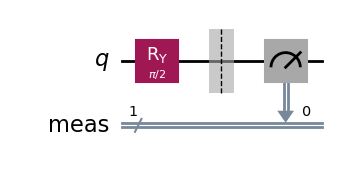

In [3]:
from qiskit import QuantumCircuit
from math import pi

qc = QuantumCircuit(1)

qc.ry(pi/2, 0)
qc.measure_all()
qc.draw('mpl', filename='single_qubit_circuit.png')

Unitary decomposition

In [14]:
import numpy as np

from numpy import pi
from scipy.linalg import det

from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.synthesis import OneQubitEulerDecomposer

np.set_printoptions(precision=5, suppress=True)

### Matrix validation

In [15]:
def is_square(matrix):

    matrix = np.array(matrix)

    return matrix.shape[0] == matrix.shape[1]

def is_2x2(matrix):

    matrix = np.array(matrix)

    return matrix.shape == (2,2)

def is_unitary(U, tol=1e-10):

    U = np.array(U, dtype=complex)

    identity = np.eye(U.shape[0])

    return np.allclose(U.conj().T @ U, identity, atol=tol)

### global phase

In [16]:
def global_phase(U):

    determinant = np.linalg.det(U)

    alpha = np.angle(determinant)/2

    return alpha

def remove_global_phase(U):

    alpha = global_phase(U)

    return np.exp(-1j*alpha)*U

#### Euler Decomposition

In [17]:
def decompose_matrix(U):

    decomposer = OneQubitEulerDecomposer("ZYZ")

    qc = decomposer(U)

    angles = decomposer.angles(U)

    return qc, angles

### build rotation circuit

In [18]:
def build_rotation_circuit(beta, gamma, delta):

    qc = QuantumCircuit(1)

    qc.rz(beta,0)

    qc.ry(gamma,0)

    qc.rz(delta,0)

    return qc

### verification

In [19]:
def verify(original_matrix, circuit):

    reconstructed = Operator(circuit).data

    return np.allclose(original_matrix, reconstructed)

### display

In [20]:
def print_angles(alpha,beta,gamma,delta):

    print("-"*40)

    print(f"Global Phase α : {alpha:.6f}")

    print(f"β : {beta:.6f}")

    print(f"γ : {gamma:.6f}")

    print(f"δ : {delta:.6f}")

    print("-"*40)

### User input

In [21]:
U = np.array([
    [0,1],
    [1,0]
],dtype=complex)

In [22]:
# a = complex(input("a = "))
# b = complex(input("b = "))
# c = complex(input("c = "))
# d = complex(input("d = "))

# U = np.array([
#     [a,b],
#     [c,d]
# ])

### Validation

In [23]:
if not is_square(U):

    print("Not square")

elif not is_2x2(U):

    print("Not 2x2")

elif not is_unitary(U):

    print("Not a unitary matrix")

else:

    print("Valid Quantum Gate")

Valid Quantum Gate


### Decomposition

In [24]:
alpha = global_phase(U)

normalized = remove_global_phase(U)

qc, angles = decompose_matrix(normalized)

beta, gamma, delta = angles

print_angles(alpha,beta,gamma,delta)

----------------------------------------
Global Phase α : 1.570796
β : 3.141593
γ : -1.570796
δ : 1.570796
----------------------------------------


Draw circuit

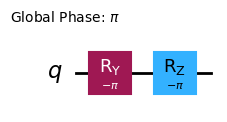

In [25]:
display(qc.draw("mpl"))

In [26]:
# Matrix Reconstruction

In [27]:
reconstructed = Operator(qc).data

print(reconstructed)

[[-0.-0.j -0.-1.j]
 [-0.-1.j  0.+0.j]]


## compair

In [28]:
print(np.allclose(normalized,reconstructed))

True


## A,B,C

In [29]:
A = Rx(beta) @ Ry(gamma/2)

B = Ry(-gamma/2) @ Rz(-(delta+beta)/2)

C = Rz((delta+beta)/2)

NameError: name 'Rx' is not defined

In [30]:
def Rx(theta):

    return np.array([
        [np.cos(theta/2),-1j*np.sin(theta/2)],
        [-1j*np.sin(theta/2),np.cos(theta/2)]
    ])
    
def Ry(theta):

    return np.array([
        [np.cos(theta/2),-np.sin(theta/2)],
        [np.sin(theta/2),np.cos(theta/2)]
    ])  
    
def Rz(theta):

    return np.array([
        [np.exp(-1j*theta/2),0],
        [0,np.exp(1j*theta/2)]
    ])      

In [31]:
A = Rx(beta) @ Ry(gamma/2)

B = Ry(-gamma/2) @ Rz(-(delta+beta)/2)

C = Rz((delta+beta)/2)

print(A)
print()

print(B)
print()

print(C)

[[ 0.+0.38268j  0.-0.92388j]
 [-0.-0.92388j  0.-0.38268j]]

[[ 0.35355+0.85355j -0.14645+0.35355j]
 [ 0.14645+0.35355j  0.35355-0.85355j]]

[[0.38268-0.92388j 0.     +0.j     ]
 [0.     +0.j      0.38268+0.92388j]]


In [6]:
from qiskit.circuit.library import GroverOperator, PhaseOracle

# Truth table as a Boolean function:
# f(0,0)=0, f(0,1)=1, f(1,0)=1, f(1,1)=0
# This is XOR.
expression = '(x & ~y) | (~x & y)'

# Automatically synthesizes the oracle from the Boolean expression
oracle = PhaseOracle(expression)

# Use in Grover's algorithm
grover = GroverOperator(oracle)

C:\Users\Pratik Giri\AppData\Local\Temp\ipykernel_19116\1916824875.py:12: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  grover = GroverOperator(oracle)
